# Notebook to create the dataframe for the analysis of the data

In [60]:
import json
import geopandas as gpd
import pandas as pd
import sys
import os
sys.path.append(os.path.join(os.path.join(os.getcwd(), '../')))
from utilities.common_functions import create_historical_dataframe, clean_dataframe
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
gdf = gpd.read_file('../data/stations_files/stations_area_of_interest.geojson')
stations_names = gdf['station'].tolist()
years = range(2019, 2024)
with open('../data/stations_files/no_historical_data_stations.json', 'r') as f:
    no_historical_data_stations = json.load(f)

# create array of empty dataframes
years_dataframes = []
for year in years:
    years_dataframes.append(pd.DataFrame())


In [ ]:
for ind, year in enumerate(years):
    for station_name in stations_names:
        if station_name not in no_historical_data_stations[str(year)]:   
            years_dataframes[ind] = create_historical_dataframe(str(station_name), year, years_dataframes[ind], gdf)
    
        



## Saving the csv

In [ ]:
for ind, year_dataframe in enumerate(years_dataframes):
    years_dataframes[ind] = clean_dataframe(year_dataframe)
    years_dataframes[ind].to_csv(f'../data/years_dataframe/{year}_data.csv')

## Loading the csv and creating a netcdf

In [102]:
unwanted_values = [99.0, 999.0, 9999.0]
for ind, year in enumerate(years):
    year_dataframe = pd.read_csv(f'../data/years_dataframe/{year}_data.csv')  
    year_dataframe['station_id'] = year_dataframe['station_id'].astype('str')
    year_dataframe['datetime'] = pd.to_datetime(year_dataframe['datetime'])
    year_dataframe['time'] = [t.astype('datetime64[h]') for t in year_dataframe.datetime.values]
    year_dataframe = year_dataframe[~year_dataframe[['WDIR', 'WSPD']].isin(unwanted_values).any(axis=1)]
    # Replace the specified values with NaN
    year_dataframe.replace(unwanted_values, np.nan, inplace=True)
    year_dataframe.loc[:, 'u_velocity'] = year_dataframe['WDIR'].apply(lambda x: np.cos(np.radians(270 - x))) * year_dataframe['WSPD']
    year_dataframe.loc[:, 'v_velocity'] = year_dataframe['WDIR'].apply(lambda x: np.sin(np.radians(270 - x))) * year_dataframe['WSPD']
    longitudes = year_dataframe.groupby('station_id').mean()['longitude']
    latitudes = year_dataframe.groupby('station_id').mean()['latitude']
    ds = year_dataframe.groupby(['station_id','time']).mean().drop(columns=['WDIR', 'WSPD', 'longitude', 'latitude', 'datetime']).to_xarray()   
    ds['latitude'] = (('station_id'), latitudes)
    ds['longitude'] = (('station_id'), longitudes)
    ds.to_netcdf(f'../data/years_dataframe/{year}_data.nc')


/var/folders/q7/f8dwgjdx3yz9l8nhprlwzdjw0000gn/T/ipykernel_42969/3696735509.py:3: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  year_dataframe = pd.read_csv(f'../data/years_dataframe/{year}_data.csv')
/var/folders/q7/f8dwgjdx3yz9l8nhprlwzdjw0000gn/T/ipykernel_42969/3696735509.py:3: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  year_dataframe = pd.read_csv(f'../data/years_dataframe/{year}_data.csv')
/var/folders/q7/f8dwgjdx3yz9l8nhprlwzdjw0000gn/T/ipykernel_42969/3696735509.py:3: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  year_dataframe = pd.read_csv(f'../data/years_dataframe/{year}_data.csv')
/var/folders/q7/f8dwgjdx3yz9l8nhprlwzdjw0000gn/T/ipykernel_42969/3696735509.py:3: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  year_dataframe = pd.read_csv(f'../data/years_

In [ ]:
year=2019
year_dataframe = pd.read_csv(f'../data/years_dataframe/{year}_data.csv')  
year_dataframe['station_id'] = year_dataframe['station_id'].astype('str')
year_dataframe['datetime'] = pd.to_datetime(year_dataframe['datetime'])
year_dataframe = year_dataframe[~year_dataframe[['WDIR', 'WSPD']].isin(unwanted_values).any(axis=1)].drop(columns=['latitude', 'longitude']).drop_duplicates(subset=['station_id', 'datetime']).set_index(['datetime', 'station_id']).to_xarray()  

In [75]:
year=2019
year_dataframe = pd.read_csv(f'../data/years_dataframe/{year}_data.csv')  
year_dataframe['station_id'] = year_dataframe['station_id'].astype('str')
year_dataframe['datetime'] = pd.to_datetime(year_dataframe['datetime'])
year_dataframe['time'] = [t.astype('datetime64[h]') for t in year_dataframe.datetime.values]

# List of values representing missing data
missing_values = [99.0, 999.0, 9999.0]
year_dataframe = year_dataframe[~year_dataframe[['WDIR', 'WSPD']].isin(missing_values).any(axis=1)]
# Replace the specified values with NaN
year_dataframe.replace(missing_values, np.nan, inplace=True)


# year_dataframe = year_dataframe[~year_dataframe[['WDIR', 'WSPD']].isin(unwanted_values).any(axis=1)].drop(columns=['latitude', 'longitude']).drop_duplicates(subset=['station_id', 'datetime']).set_index(['datetime', 'station_id'])

# year_dataframe = year_dataframe.to_xarray()

/var/folders/q7/f8dwgjdx3yz9l8nhprlwzdjw0000gn/T/ipykernel_42969/3418545389.py:2: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  year_dataframe = pd.read_csv(f'../data/years_dataframe/{year}_data.csv')


In [76]:
year_dataframe

,datetime,WDIR,WSPD,GST,PRES,ATMP,WTMP,DEWP,station_id,latitude,longitude,time
0,2019-04-01 00:00:00,56,4.8,6.7,NaN,NaN,13.4,NaN,44041,37.211,-76.787,2019-04-01 00:00:00
1,2019-04-01 00:06:00,42,4.1,5.2,NaN,NaN,13.4,NaN,44041,37.211,-76.787,2019-04-01 00:00:00
2,2019-04-01 00:12:00,36,3.5,4.5,NaN,NaN,13.4,NaN,44041,37.211,-76.787,2019-04-01 00:00:00
3,2019-04-01 00:18:00,35,3.2,3.9,NaN,NaN,13.4,NaN,44041,37.211,-76.787,2019-04-01 00:00:00
4,2019-04-01 00:24:00,31,3.0,3.7,NaN,NaN,13.4,NaN,44041,37.211,-76.787,2019-04-01 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...
7685263,2019-12-31 19:00:00,135,5.7,6.1,1005.7,7.0,6.4,6.8,TPLM2,38.899,-76.436,2019-12-31 19:00:00
7685264,2019-12-31 20:00:00,147,6.7,8.4,1005.2,7.7,6.4,6.1,TPLM2,38.899,-76.436,2019-12-31 20:00:00
7685265,2019-12-31 21:00:00,206,5.6,5.9,1005.5,10.5,6.5,0.6,TPLM2,38.899,-76.436,2019-12-31 21:00:00
7685266,2019-12-31 22:00:00,222,6.8,7.3,1005.8,10.4,6.5,-1.2,TPLM2,38.899,-76.436,2019-12-31 22:00:00


In [78]:
year_dataframe.loc[:, 'u_velocity'] = year_dataframe['WDIR'].apply(lambda x: np.cos(np.radians(270 - x))) * year_dataframe['WSPD']
year_dataframe.loc[:, 'v_velocity'] = year_dataframe['WDIR'].apply(lambda x: np.sin(np.radians(270 - x))) * year_dataframe['WSPD']

In [99]:
longitudes = year_dataframe.groupby('station_id').mean()['longitude']
latitudes = year_dataframe.groupby('station_id').mean()['latitude']

In [85]:
ds = year_dataframe.groupby(['station_id','time']).mean().drop(columns=['WDIR', 'WSPD', 'longitude', 'latitude', 'datetime']).to_xarray()   

In [91]:
year_dataframe['latitude'].values

array([37.211, 37.211, 37.211, ..., 38.899, 38.899, 38.899])

In [100]:
ds['latitude'] = (('station_id'), latitudes)
ds['longitude'] = (('station_id'), longitudes)

In [101]:
ds.sel(station_id='44005').latitude


<xarray.DataArray 'latitude' ()> Size: 8B
array(43.201)
Coordinates:
    station_id  <U5 20B '44005'

In [77]:
year_dataframe.groupby(['time', 'station_id']).mean().drop(columns=)

datetime   WDIR    WSPD    GST  \
time                station_id                                             
2018-12-31 23:00:00 44017      2018-12-31 23:50:00  152.0  9.8000  11.50   
                    44018      2018-12-31 23:50:00  171.0  7.7000   9.30   
                    44025      2018-12-31 23:50:00  147.0  9.8000  12.50   
2019-01-01 00:00:00 44007      2019-01-01 00:50:00  200.0  9.3000  10.80   
                    44013      2019-01-01 00:50:00  158.0  9.6000  11.50   
...                                            ...    ...     ...    ...   
2019-12-31 23:00:00 WAHV2      2019-12-31 23:27:00  246.1  1.3900   2.13   
                    WASD2      2019-12-31 23:27:00  266.0  2.8900   4.56   
                    WELM1      2019-12-31 23:27:00  326.5  1.5800   2.30   
                    YKRV2      2019-12-31 23:28:30  235.0  5.4625   5.95   
                    YKTV2      2019-12-31 23:27:00  228.9  3.1700   4.13   

                                   PRES    ATMP   WTMP  DEWP  latitude  \
time                station_id                                           
2018-12-31 23:00:00 44017       1022.90   6.700   8.00   3.8    40.693   
                    44018       1025.30   4.300    NaN  -2.0    42.203   
                    44025       1020.70   7.600   7.10   NaN    40.258   
2019-01-01 00:00:00 44007       1022.60   5.300   5.00   0.8    43.525   
                    44013       1023.70   3.600   7.00   1.5    42.346   
...                                 ...     ...    ...   ...       ...   
2019-12-31 23:00:00 WAHV2       1006.73   7.670  11.08   NaN    37.608   
                    WASD2       1005.75  10.730   4.70   NaN    38.873   
                    WELM1       1000.63   0.590   4.73   NaN    43.320   
                    YKRV2       1007.70  10.625    NaN   NaN    37.251   
                    YKTV2       1006.81  10.780   8.89   NaN    37.227   

                                longitude  
time                station_id             
2018-12-31 23:00:00 44017         -72.049  
                    44018         -70.154  
                    44025         -73.175  
2019-01-01 00:00:00 44007         -70.140  
                    44013         -70.651  
...                                   ...  
2019-12-31 23:00:00 WAHV2         -75.686  
                    WASD2         -77.021  
                    WELM1         -70.563  
                    YKRV2         -76.342  
                    YKTV2         -76.479  

[755974 rows x 10 columns]

In [73]:
year_dataframe['time'] = [t.astype('datetime64[h]') for t in year_dataframe.datetime.values]

In [74]:
year_dataframe.groupby(['time', 'station_id']).mean()

,datetime,WDIR,WSPD,GST,PRES,ATMP,WTMP,DEWP,station_id,latitude,longitude,time
0,2019-04-01 00:00:00,56,4.8,6.7,9999.0,999.0,13.4,999.0,44041,37.211,-76.787,2019-04-01 00:00:00
1,2019-04-01 00:06:00,42,4.1,5.2,9999.0,999.0,13.4,999.0,44041,37.211,-76.787,2019-04-01 00:00:00
2,2019-04-01 00:12:00,36,3.5,4.5,9999.0,999.0,13.4,999.0,44041,37.211,-76.787,2019-04-01 00:00:00
3,2019-04-01 00:18:00,35,3.2,3.9,9999.0,999.0,13.4,999.0,44041,37.211,-76.787,2019-04-01 00:00:00
4,2019-04-01 00:24:00,31,3.0,3.7,9999.0,999.0,13.4,999.0,44041,37.211,-76.787,2019-04-01 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...
7702554,2019-12-31 21:30:00,999,99.0,99.0,9999.0,999.0,8.8,999.0,44097,40.967,-71.124,2019-12-31 21:00:00
7702555,2019-12-31 22:00:00,999,99.0,99.0,9999.0,999.0,8.8,999.0,44097,40.967,-71.124,2019-12-31 22:00:00
7702556,2019-12-31 22:30:00,999,99.0,99.0,9999.0,999.0,8.8,999.0,44097,40.967,-71.124,2019-12-31 22:00:00
7702557,2019-12-31 23:00:00,999,99.0,99.0,9999.0,999.0,8.8,999.0,44097,40.967,-71.124,2019-12-31 23:00:00


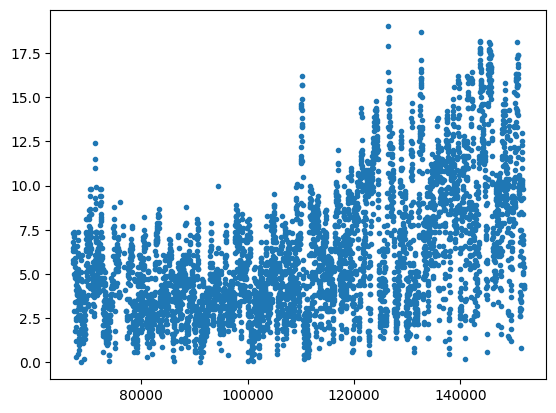

In [61]:
np.sum(~np.isnan(year_dataframe.sel(station_id='44005').WSPD.values))

plt.plot(year_dataframe.sel(station_id='44005').WSPD.values, '.')

In [27]:
# Convert string to pandas Timestamp
timestamp = pd.Timestamp('2019-01-01 00:00:00')

In [28]:
timestamp

Timestamp('2019-01-01 00:00:00')

In [34]:
years_dataframes[0]

<xarray.Dataset> Size: 988MB
Dimensions:     (datetime: 157293, station_id: 112)
Coordinates:
  * datetime    (datetime) datetime64[ns] 1MB 2018-12-31T23:50:00 ... 2019-12...
  * station_id  (station_id) object 896B '44005' '44007' ... 'YKRV2' 'YKTV2'
Data variables:
    WDIR        (datetime, station_id) float64 141MB nan nan nan ... 235.0 225.0
    WSPD        (datetime, station_id) float64 141MB nan nan nan ... nan 5.1 3.9
    GST         (datetime, station_id) float64 141MB nan nan nan ... nan 5.5 5.0
    PRES        (datetime, station_id) float64 141MB nan nan ... 1.007e+03
    ATMP        (datetime, station_id) float64 141MB nan nan nan ... 10.4 10.6
    WTMP        (datetime, station_id) float64 141MB nan nan nan ... 999.0 8.9
    DEWP        (datetime, station_id) float64 141MB nan nan nan ... 999.0 999.0

In [29]:
print(type(years_dataframes[0].coords['datetime'].values[0]))

<class 'numpy.datetime64'>


In [36]:
years_dataframes[0].sel(station_id='44009').to_dataframe()

,WDIR,WSPD,GST,PRES,ATMP,WTMP,DEWP,station_id
datetime,,,,,,,,
2018-12-31 23:50:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44009
2019-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44009
2019-01-01 00:04:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44009
2019-01-01 00:06:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44009
2019-01-01 00:10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44009
...,...,...,...,...,...,...,...,...
2019-12-31 23:42:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44009
2019-12-31 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44009
2019-12-31 23:48:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44009
